# A Machine Learning Approach to Job Salary Prediction

## 1. Objective:

This project demonstrates an end-to-end machine learning workflow for prediction. It covers data cleaning, preprocessing, and feature engineering, followed by the implementation of ordinal logistic regression. Model performance is evaluated and compared using appropriate metrics to identify the most effective predictive approach.

Importing the needed libraries:

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import linear_model

from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import make_scorer, r2_score, confusion_matrix, mean_squared_error, auc, mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

Load the project files:

In [ ]:
!git clone https://github.com/ali-sh-96/Machine-learning-Portfolio.git

# Get the path to the installed package.
root_dir = Path("Machine-learning-Portfolio")
# Select project
project_name = "project2"
project_dir = root_dir / project_name

Cloning into 'Machine-learning-Portfolio'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 135 (delta 53), reused 75 (delta 28), pack-reused 32 (from 1)
Receiving objects: 100% (135/135), 81.84 MiB | 9.10 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Updating files: 100% (29/29), done.


Loading and splitting the dataset:

In [ ]:
# Using a small subset of original data
# full data can be found on Kaggle : https://www.kaggle.com/c/job-salary-prediction

Salaries = pd.read_csv(project_dir / "Salary_Train_sample.csv", encoding = "ISO-8859-1")
Salaries_Train, Salaries_Test = train_test_split(Salaries, test_size=0.33, random_state=13)
Salaries.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


## 2. Data cleaning and preparation:

Defining the preprocessing functions:

In [ ]:
def clean_null(Salaries):
    Salaries.dropna(subset=['Title'],inplace=True)
    Salaries['ContractType'].fillna(Salaries['ContractType'].mode()[0],inplace=True)
    Salaries.loc[Salaries['ContractTime'].isnull(), 'ContractTime'] = 'Unknown'
    Salaries.loc[Salaries['Company'].isnull(), 'Company'] = 'Unknown'
    return Salaries

def featurize(Salaries_Train, Salaries_Test):

    vectorizer = CountVectorizer(analyzer = "word",
                                 tokenizer = None,
                                 preprocessor = None,
                                 stop_words = 'english',
                                 max_features = 200,
                                 ngram_range = (1,2))\
                                .fit(Salaries_Train['FullDescription'])

    train_words = vectorizer.transform(Salaries_Train['FullDescription'])
    test_words = vectorizer.transform(Salaries_Test['FullDescription'])

    title_vectorizer = vectorizer = CountVectorizer(analyzer = "word", tokenizer = None,
                                                preprocessor = None,
                                                stop_words = 'english',
                                                max_features = 200,
                                                ngram_range = (2,3))\
                                                .fit(Salaries_Train['Title'])

    train_title_words = title_vectorizer.transform(Salaries_Train['Title'])
    test_title_words = title_vectorizer.transform(Salaries_Test['Title'])

    location_counts = Salaries_Train.LocationNormalized.value_counts()
    value_mask = Salaries_Train.LocationNormalized.isin(location_counts.index[location_counts < 100])
    Salaries_Train.loc[value_mask,'LocationNormalized'] = "Other"
    Salaries_Test.loc[Salaries_Test.LocationNormalized.isin(list(location_counts.index[location_counts > 100])) == False,\
                      "LocationNormalized"] = "Other"

    Salaries_Train = pd.get_dummies(data=Salaries_Train, columns=['LocationNormalized', 'ContractType','Category','ContractTime'])
    Salaries_Test = pd.get_dummies(data=Salaries_Test, columns=['LocationNormalized', 'ContractType','Category','ContractTime'])


    # In case there are missing columns in Test
    missing_cols = set( Salaries_Train.columns ) - set(Salaries_Test.columns )
    for column in missing_cols:
        Salaries_Test[column] = 0
    Salaries_Test = Salaries_Test[Salaries_Train.columns]

    #Combine all features into sparse dataframe

    #TRAIN -------------------------------------------------------

    features_train = Salaries_Train.drop(['FullDescription',
                         'Title','Id','LocationRaw','Company',
                         'SalaryRaw','SourceName'], axis=1)
    title_train =  pd.DataFrame(data = train_title_words.toarray(), columns = title_vectorizer.get_feature_names_out())
    description_train = pd.DataFrame(data = train_words.toarray(), columns = vectorizer.get_feature_names_out())

    features_train.reset_index(drop=True, inplace=True)
    title_train.reset_index(drop=True, inplace=True)
    description_train.reset_index(drop=True, inplace=True)

    Salaries_Train = pd.concat([features_train,title_train,description_train], axis = 1)

    Salaries_Y = Salaries_Train['SalaryNormalized']
    Salaries_X = Salaries_Train.drop(['SalaryNormalized'], axis=1)

     #TEST -------------------------------------------------------

    features_test = Salaries_Test.drop(['FullDescription',
                         'Title','Id','LocationRaw','Company',
                         'SalaryRaw','SourceName'], axis=1)
    title_test =  pd.DataFrame(data = test_title_words.toarray(), columns = title_vectorizer.get_feature_names_out())
    description_test = pd.DataFrame(data = test_words.toarray(), columns = vectorizer.get_feature_names_out())

    features_test.reset_index(drop=True, inplace=True)
    title_test.reset_index(drop=True, inplace=True)
    description_test.reset_index(drop=True, inplace=True)

    Salaries_Test = pd.concat([features_test,title_test,description_test], axis = 1)

    Salaries_Y_Test = Salaries_Test['SalaryNormalized']
    Salaries_X_Test = Salaries_Test.drop(['SalaryNormalized'], axis=1)

    return Salaries_X, Salaries_Y, Salaries_X_Test, Salaries_Y_Test

Preprocessing the dataset:

In [ ]:
Salaries_Train = clean_null(Salaries_Train)
Salaries_Test = clean_null(Salaries_Test)
Salaries_X, Salaries_Y, Salaries_X_Test, Salaries_Y_Test = featurize(Salaries_Train, Salaries_Test)
print(f"Dataset shape: {Salaries_X_Test.shape}")

/tmp/ipykernel_2358/3335034998.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Salaries['ContractType'].fillna(Salaries['ContractType'].mode()[0],inplace=True)
/tmp/ipykernel_2358/3335034998.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

Dataset shape: (5940, 447)


Show all columns when displaying DataFrames:

In [ ]:
pd.set_option('display.max_columns', None)

### Data preparation workflow:

Inspecting missing values:

In [ ]:
Salaries = pd.read_csv(project_dir / "Salary_Train_sample.csv", encoding = "ISO-8859-1")
Salaries.isnull().sum(axis=0)

,0
Id,0
Title,1
FullDescription,0
LocationRaw,0
LocationNormalized,0
ContractType,10780
ContractTime,8893
Company,6111
Category,0
SalaryRaw,0


Displaying records with missing job titles:

In [ ]:
Salaries[Salaries['Title'].isna()]

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
1588,48271669,NaN,Quality Improvement Manager North West England...,"Liverpool, Merseyside",Liverpool,full_time,NaN,NaN,Healthcare & Nursing Jobs,"40,000 to 45,000 per year",42500,careworx.co.uk


Removing records with missing job titles:

In [ ]:
Salaries = Salaries.dropna(subset=['Title'])

Removing records with excessive missing values:

In [ ]:
Salaries.dropna(axis=0, thresh=9, subset=None, inplace=True)

The `ContractType` feature contains a significant number of missing values.

Inspecting contract type categories:

In [ ]:
Salaries['ContractType'].unique() # display what values 'ContractType' can have

array([nan, 'full_time', 'part_time'], dtype=object)

The distribution of the available `ContractType` categories is examined to understand the relative frequency of each class.

In [ ]:
Salaries['ContractType'].value_counts(normalize=True) # display the distiburion of the values for 'ContractType'

,proportion
ContractType,
full_time,0.842083
part_time,0.157917


### Determining the missing value handling strategy:

Missing values can be addressed using different approaches depending on the nature of the missing data and the feature characteristics. Common strategies include:

- Removing rows or columns with excessive missing values.
- Replacing missing values with statistical estimates, such as the mode for categorical variables or the mean/median for numerical variables.
- Assigning missing values to a separate category, such as `"Other"` or `"Unknown"`.

Before selecting a strategy, the distribution of missing values is examined to determine whether they occur randomly or follow a specific pattern.

In [ ]:
a = Salaries['Category'].value_counts(normalize=True) # the distribution of job categories

# the distiburion of job categories where the contract type is NaN
b = Salaries[Salaries['ContractType'].isnull()]['Category'].value_counts(normalize=True)

print (pd.DataFrame({'Alldata': a, 'NaN ContractType':b})) # is there a difference?

                                   Alldata  NaN ContractType
Category                                                    
Accounting & Finance Jobs         0.064559          0.059091
Admin Jobs                        0.025501          0.020501
Charity & Voluntary Jobs          0.007889          0.006772
Consultancy Jobs                  0.012334          0.008813
Creative & Design Jobs            0.004000          0.001855
Customer Services Jobs            0.026057          0.024861
Domestic help & Cleaning Jobs     0.001056          0.001113
Energy, Oil & Gas Jobs            0.004111          0.005473
Engineering Jobs                  0.095172          0.115863
Graduate Jobs                     0.001667          0.000742
HR & Recruitment Jobs             0.042558          0.059740
Healthcare & Nursing Jobs         0.223901          0.188683
Hospitality & Catering Jobs       0.050447          0.064750
IT Jobs                           0.149064          0.187662
Legal Jobs              

The comparison between the overall job category distribution and the distribution of records with missing `ContractType` values shows no significant difference. This suggests that the missing values are not strongly associated with specific job categories.

Therefore, missing `ContractType` values are replaced with the most frequent category (mode). This approach preserves the available samples while minimizing the risk of introducing bias.

In [ ]:
Salaries['ContractType'].fillna(Salaries['ContractType'].mode()[0],inplace=True)

/tmp/ipykernel_2358/3915413261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Salaries['ContractType'].fillna(Salaries['ContractType'].mode()[0],inplace=True)


The distribution of the `ContractTime` feature is examined next.

In [ ]:
Salaries['ContractTime'].value_counts(normalize=True)

,proportion
ContractTime,
permanent,0.845833
contract,0.154167


To determine whether missing `ContractTime` values occur randomly, the distribution of job categories among records with missing `ContractTime` is compared with the overall job category distribution.

If the two distributions are similar, missing values are likely independent of job category. If noticeable differences exist, the missing values require additional consideration during preprocessing.

In [ ]:
a = Salaries['Category'].value_counts(normalize=True)
b = Salaries[Salaries['ContractTime'].isnull()]['Category'].value_counts(normalize=True)
print (pd.DataFrame({'Alldata': a, 'NaN ContractTime':b}))

                                   Alldata  NaN ContractTime
Category                                                    
Accounting & Finance Jobs         0.064559          0.044647
Admin Jobs                        0.025501          0.037000
Charity & Voluntary Jobs          0.007889          0.001350
Consultancy Jobs                  0.012334          0.015857
Creative & Design Jobs            0.004000          0.002474
Customer Services Jobs            0.026057          0.033288
Domestic help & Cleaning Jobs     0.001056          0.001462
Energy, Oil & Gas Jobs            0.004111          0.003036
Engineering Jobs                  0.095172          0.037562
Graduate Jobs                     0.001667          0.002474
HR & Recruitment Jobs             0.042558          0.036550
Healthcare & Nursing Jobs         0.223901          0.419703
Hospitality & Catering Jobs       0.050447          0.091430
IT Jobs                           0.149064          0.021480
Legal Jobs              

There is a higher proportion of jobs in healthcare, hospitality and catering and 'other' where the contract time is NaN. Although this may require some futher exploration, we will now fill them with a filler 'Unknown' variable.

In [ ]:
Salaries.loc[Salaries['ContractTime'].isnull(), 'ContractTime'] = 'Unknown'

Next, let's deal with missing values in the 'Company' column

In [ ]:
Salaries[Salaries['Company'].isnull()]['FullDescription'].iloc[0:10]

,FullDescription
86,An exciting job opportunity has arisen to work...
93,Job Title: Java Developer Location: Yorkshire ...
113,Transaction Services Executive **** **** plus...
114,"Audit Senior **** Bristol My client, a reputab..."
115,Audit Assistant Manager Bristol **** **** This...
120,Sales Account Executive Basingstoke Salary ***...
130,Excellent new job and career opportunity for a...
137,Barclays are hiring. Future Leaders Developmen...
153,"Our client, a global service provider, require..."
182,Support Worker Job Chepstow We are a leading p...


Missing companies names can be caused by a variety of factors. Some postings may have the company name in the full description, while others are third party recruiters, recruiting for a client. NaNs will be filled with an 'Unknown' value. This value might capture recruitment by a third party. This could be further refined, for example filling with 'Third Party' if Description contains 'Client'.

In [ ]:
Salaries.loc[Salaries['Company'].isnull(), 'Company'] = 'Unknown'

### Cleaning text data:

The dataset contains a significant amount of uncleaned and unstructured text in the 'Title' and 'Full Description' columns.
A simple approach would be to clean up the text, remove stop words (useless words such as 'by', 'such'), and do one-hot encoding using CountVectorizer.

In [ ]:
# Configuring CountVectorizer
vectorizer = CountVectorizer(analyzer = "word",
                             tokenizer = None,
                             preprocessor = None,
                             stop_words = 'english',
                             max_features = 200,
                             ngram_range = (1,2))

In [ ]:
# Vectorizing job descriptions

Words = vectorizer.fit_transform(Salaries['FullDescription'])
print(vectorizer.get_feature_names_out()[0:25])

['ability' 'able' 'agency' 'applicants' 'application' 'applications'
 'apply' 'appropriate' 'area' 'areas' 'assist' 'available' 'background'
 'based' 'basis' 'benefits' 'best' 'business' 'candidate' 'candidates'
 'care' 'career' 'chef' 'client' 'clients']


The most common words seem to be relevant to salary information, although some stopwords could possibly be added to the vectors as well. A better approach may be to set a high number of max_features and run a linear regression for feature selection.

Several of the most frequent words such as 'car, 'linux', 'worker', 'digital', look like they belong to a sequence of words, so the vectorizer could benefit from using n-grams.

In [ ]:
title_vectorizer = CountVectorizer(analyzer = "word", tokenizer = None,
                                                preprocessor = None,
                                                stop_words = 'english',
                                                max_features = 200,
                                                ngram_range = (2,3))

Title_Words = title_vectorizer.fit_transform(Salaries['Title'])
print(title_vectorizer.get_feature_names_out()[0:10])

['account director' 'account executive' 'account manager'
 'accounts assistant' 'assistant job' 'assistant jobs' 'assistant manager'
 'award winning' 'branch manager' 'building services']


The features from n-grams seem more appropriate.

## 3. Combining multiple categorical values into a single category:

Checking the number of unique companies:

In [ ]:
Salaries["Company"].nunique() # number of unique company names

3598

Because there are a lot of unique company names, it may be excessive to get dummies for each one, and there may not be enough examples of each company name to be significant in model training. An option would be to get dummy variables for the top 100 most popular companies or companies above a threshold count.

Checking the number of unique locations:

In [ ]:
Salaries["LocationNormalized"].nunique() # number of unique company locations

1198

There is also a significant amount of unique Company locations (1000+). To allow the models to run in reasonable time and eliminate locations that only appear once, we will only consider locations that appear above a certain frequency. Everything else we can replace with "Other".

Grouping rare locations:

In [ ]:
location_counts = Salaries.LocationNormalized.value_counts()

# Mask the locations that appear less than 100 times in the data
value_mask = Salaries.LocationNormalized.isin(location_counts.index[location_counts < 100])
Salaries.loc[value_mask,'LocationNormalized'] = "Other"

Checking remaining location categories:

In [ ]:
Salaries.LocationNormalized.nunique()

26

Since the other features are non-ordinal categorical features, they can be encoded using dummy variables.

In [ ]:
Salaries = pd.get_dummies(data=Salaries, columns=['LocationNormalized', 'ContractType','Category','ContractTime'])

## 4. Combining features:

Combining all features into a single matrix:

In [ ]:
features = Salaries.drop(['FullDescription',
                         'Title','Id','LocationRaw','Company',
                         'SalaryRaw','SalaryNormalized','SourceName'], axis=1).values

Title_Features = Title_Words.toarray()
Description_Features = Words.toarray()

all_features = np.hstack([features, Title_Features, Description_Features])

Combining all features into a dataframe:

In [ ]:
features = Salaries.drop(['FullDescription',
                         'Title','Id','LocationRaw','Company',
                         'SalaryRaw','SalaryNormalized','SourceName'], axis=1)
title =  pd.DataFrame(data = Title_Words.toarray(), columns = title_vectorizer.get_feature_names_out())
description = pd.DataFrame(data = Words.toarray(), columns = vectorizer.get_feature_names_out())

features.reset_index(drop=True, inplace=True)
title.reset_index(drop=True, inplace=True)
description.reset_index(drop=True, inplace=True)

Salaries_Feature = pd.concat([features,title,description], axis = 1)

In [ ]:
Salaries.head()

,Id,Title,FullDescription,LocationRaw,Company,SalaryRaw,SalaryNormalized,SourceName,LocationNormalized_Belfast,LocationNormalized_Berkshire,LocationNormalized_Birmingham,LocationNormalized_Bradford,LocationNormalized_Bristol,LocationNormalized_Cambridge,LocationNormalized_Central London,LocationNormalized_Edinburgh,LocationNormalized_Glasgow,LocationNormalized_Hampshire,LocationNormalized_Hertfordshire,LocationNormalized_Leeds,LocationNormalized_Leicester,LocationNormalized_Liverpool,LocationNormalized_London,LocationNormalized_Manchester,LocationNormalized_Newcastle Upon Tyne,LocationNormalized_Nottingham,LocationNormalized_Other,LocationNormalized_Reading,LocationNormalized_Sheffield,LocationNormalized_South East London,LocationNormalized_Surrey,LocationNormalized_The City,LocationNormalized_UK,LocationNormalized_West Midlands,ContractType_full_time,ContractType_part_time,Category_Accounting & Finance Jobs,Category_Admin Jobs,Category_Charity & Voluntary Jobs,Category_Consultancy Jobs,Category_Creative & Design Jobs,Category_Customer Services Jobs,Category_Domestic help & Cleaning Jobs,"Category_Energy, Oil & Gas Jobs",Category_Engineering Jobs,Category_Graduate Jobs,Category_HR & Recruitment Jobs,Category_Healthcare & Nursing Jobs,Category_Hospitality & Catering Jobs,Category_IT Jobs,Category_Legal Jobs,Category_Logistics & Warehouse Jobs,Category_Maintenance Jobs,Category_Manufacturing Jobs,Category_Other/General Jobs,"Category_PR, Advertising & Marketing Jobs",Category_Property Jobs,Category_Retail Jobs,Category_Sales Jobs,Category_Scientific & QA Jobs,Category_Social work Jobs,Category_Teaching Jobs,Category_Trade & Construction Jobs,Category_Travel Jobs,ContractTime_Unknown,ContractTime_contract,ContractTime_permanent
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Gregory Martin International,20000 - 30000/annum 20-30K,25000,cv-library.co.uk,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Gregory Martin International,25000 - 35000/annum 25-35K,30000,cv-library.co.uk,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Gregory Martin International,20000 - 40000/annum 20-40K,30000,cv-library.co.uk,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Gregory Martin International,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,12613647,"P

## 5. Exploratory data analysis:

Plot the distribution of normalized salaries:

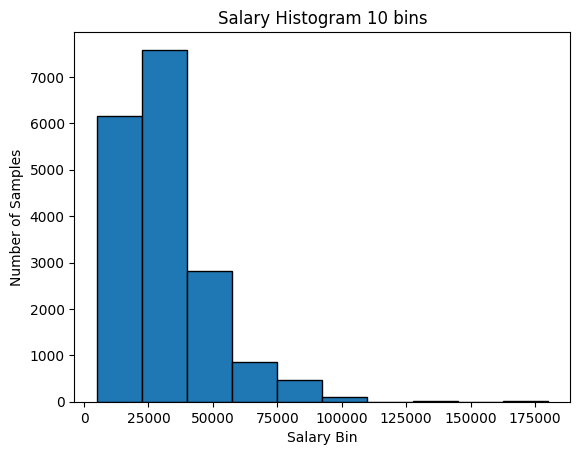

In [ ]:
Salaries_Plot = pd.read_csv(project_dir / "Salary_Train_sample.csv", encoding = "ISO-8859-1")

%matplotlib inline

plt.hist(Salaries_Plot['SalaryNormalized'], bins=10, edgecolor='black')
plt.title("Salary Histogram 10 bins")
plt.xlabel("Salary Bin")
plt.ylabel("Number of Samples")
plt.show()

## 6. Linear regression:

In [ ]:
# Defining K-fold cross-validation

def run_kfold(model):

    X = Salaries_X
    Y = Salaries_Y

    kf = KFold(n_splits=10) #n_splits previously n_folds

    scores = []
    fold = 0

    for train_index, test_index in kf.split(X):
        fold += 1
        X_train, X_test = X.values[train_index], X.values[test_index]
        Y_train, Y_test = Y.values[train_index], Y.values[test_index]

        model.fit(X_train, Y_train)
        predictions = model.predict(X_test)

        score = r2_score(Y_test, predictions) # can try different metrics (e.g., Mean absolute error)
        scores.append(score)
        print("Fold {0} R2 score: {1}".format(fold, score))

    mean_score = np.mean(scores)
    std_score=np.std(scores)
    print("Mean R2 score: {0}".format(mean_score))
    print("Standard Deviation: {0}".format(std_score))

Training and evaluating a linear regression baseline:

In [ ]:
model_lr = linear_model.LinearRegression()
run_kfold (model_lr)

predictions = model_lr.predict(Salaries_X_Test)
Test_Score = r2_score(Salaries_Y_Test, predictions)

print ("------------------\n Test Score: " + str(Test_Score))


Fold 1 R2 score: 0.44023525705208966
Fold 2 R2 score: 0.42575619639750106
Fold 3 R2 score: 0.418267598240313
Fold 4 R2 score: 0.4390097464906644
Fold 5 R2 score: 0.47200294093002193
Fold 6 R2 score: 0.46004225733636694
Fold 7 R2 score: 0.4230622534563908
Fold 8 R2 score: 0.42227448586733674
Fold 9 R2 score: 0.4369596302145077
Fold 10 R2 score: 0.4941295208439933
Mean R2 score: 0.4431739886829186
Standard Deviation: 0.023540788910728173
------------------
 Test Score: 0.44832663093914094


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Examining feature coefficients:

In [ ]:
print(sorted(list(zip(model_lr.coef_, Salaries_X)))[0:10])
print(sorted(list(zip(model_lr.coef_, Salaries_X)),reverse=True)[0:10])

[(np.float64(-15405.863504876104), 'Category_Graduate Jobs'), (np.float64(-14921.885769881268), 'dental nurse'), (np.float64(-14867.405313081512), 'senior recruitment'), (np.float64(-14009.653766366497), 'teaching assistant'), (np.float64(-13546.344579248722), 'assistant job'), (np.float64(-12134.931882793113), 'general nurse'), (np.float64(-10680.684301676403), 'healthcare assistant'), (np.float64(-9940.061568860645), 'staff nurse elderly'), (np.float64(-9846.517644964155), 'care workers'), (np.float64(-9757.713236643871), 'accounts assistant')]
[(np.float64(35752.7930314188), 'nurse practitioner'), (np.float64(20553.35139721774), 'intensive care'), (np.float64(17047.290155759245), 'Category_Energy, Oil & Gas Jobs'), (np.float64(16662.154789996137), 'senior recruitment consultant'), (np.float64(13384.681426031288), 'self employed'), (np.float64(11654.975396892862), 'live care worker'), (np.float64(11174.633432719618), 'finance manager'), (np.float64(10902.762228492516), 'care assistan

Coefficients seem very high, try regulatization and feature elimination.

## 7. Recursive feature elimination:

scikit-learn:

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through a coef_ attribute or through a feature_importances_ attribute. Then, the least important features are pruned from current set of features. That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [ ]:
# Sampling because of slow run time.

rfe = RFE(model_lr)
fit = rfe.fit(Salaries_X[0:10000], Salaries_Y[0:10000])
sorted(list(zip(fit.ranking_,Salaries_X))[0:10])

[(np.int64(1), 'LocationNormalized_Belfast'),
 (np.int64(1), 'LocationNormalized_Hampshire'),
 (np.int64(1), 'LocationNormalized_Leeds'),
 (np.int64(1), 'LocationNormalized_Liverpool'),
 (np.int64(1), 'LocationNormalized_London'),
 (np.int64(1), 'LocationNormalized_Manchester'),
 (np.int64(1), 'LocationNormalized_Sheffield'),
 (np.int64(26), 'LocationNormalized_Other'),
 (np.int64(86), 'LocationNormalized_Bristol'),
 (np.int64(141), 'LocationNormalized_Birmingham')]

## 8. Lasso regularization:

Lasso (Least Absolute Shrinkage and Selection Operator) regression is a linear regression method that applies an L1 regularization penalty to the model coefficients. For more information, see the scikit-learn documentation:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

Training Lasso regression:

In [ ]:
reg = linear_model.Lasso(alpha = 0.5,max_iter=10000)
reg.fit(Salaries_X, Salaries_Y)
reg.score(Salaries_X, Salaries_Y) # R2 score

0.48044560307389994

Search for the best Lasso regularization parameter using cross-validation.

In [ ]:
reg_gridsearch = linear_model.Lasso(random_state=42)
#Parameters to test
parameters = {'alpha':[0.5,1,3], # Constant that multiplies the L1 term. Defaults to 1.0.
              } #

# Compare parameters by score of model
acc_scorer_lm = make_scorer(r2_score)

# Run the grid search
grid_obj_lm = GridSearchCV(reg_gridsearch, parameters, scoring=acc_scorer_lm)
grid_obj_lm = grid_obj_lm.fit(Salaries_X, Salaries_Y)

reg_gridsearch = grid_obj_lm.best_estimator_  #Select best parameter combination
reg_gridsearch # print out the optimal params so grid search does not need to be rerun

Lasso(alpha=3, random_state=42)

Evaluating optimized Lasso model:

In [ ]:
reg_gridsearch.fit(Salaries_X, Salaries_Y)
reg_gridsearch.score(Salaries_X, Salaries_Y)

0.4774476634820015

In [ ]:
print('alpha (Constant that multiplies the L1 term):',grid_obj_lm.best_estimator_.alpha)

alpha (Constant that multiplies the L1 term): 3


Calculate test error and cross-validation performance:

In [ ]:
predictions_lasso=reg_gridsearch.predict(Salaries_X_Test)
mean_absolute_error(Salaries_Y_Test,predictions_lasso)
run_kfold(reg)

Fold 1 R2 score: 0.4413346501449382
Fold 2 R2 score: 0.4270764346545145
Fold 3 R2 score: 0.41889293516118065
Fold 4 R2 score: 0.4394990464324712
Fold 5 R2 score: 0.47345659282016894
Fold 6 R2 score: 0.46043625135462607
Fold 7 R2 score: 0.423095158129137
Fold 8 R2 score: 0.4221986361301143
Fold 9 R2 score: 0.4382852263827891
Fold 10 R2 score: 0.4945080501705722
Mean R2 score: 0.4438782981380512
Standard Deviation: 0.023617496050991803


We see more consistent results with regularization than regular linear regression.

In [ ]:
# Display features with the largest Lasso coefficients
lasso_coefficients = list(zip(reg.coef_, Salaries_X.columns))

print("Most influential Lasso features:")
print(sorted(lasso_coefficients, reverse=True)[:10])

# Apply RFE using Lasso
rfe_lasso = RFE(reg)

fit_lasso = rfe_lasso.fit(
    Salaries_X[0:10000],
    Salaries_Y[0:10000]
)

# Compare with Linear Regression coefficients
linear_coefficients = list(zip(model_lr.coef_, Salaries_X.columns))

print("\nMost influential Linear Regression features:")
print(sorted(linear_coefficients, reverse=True)[:10])

Most influential Lasso features:
[(np.float64(35697.39989270395), 'nurse practitioner'), (np.float64(20209.29119940592), 'intensive care'), (np.float64(17281.937329001263), 'Category_Energy, Oil & Gas Jobs'), (np.float64(13027.356005635687), 'self employed'), (np.float64(10972.608537539974), 'finance manager'), (np.float64(10067.378533722445), 'social worker'), (np.float64(9997.904904936766), 'Category_Healthcare & Nursing Jobs'), (np.float64(9676.155779214701), 'LocationNormalized_The City'), (np.float64(9249.763507540372), 'systems engineer'), (np.float64(9071.399868417979), 'care assistant job')]

Most influential Linear Regression features:
[(np.float64(35752.7930314188), 'nurse practitioner'), (np.float64(20553.35139721774), 'intensive care'), (np.float64(17047.290155759245), 'Category_Energy, Oil & Gas Jobs'), (np.float64(16662.154789996137), 'senior recruitment consultant'), (np.float64(13384.681426031288), 'self employed'), (np.float64(11654.975396892862), 'live care worker'), 

## 9. PCA:

Apply PCA and evaluate performance:

In [ ]:
pca = PCA(n_components=150)
pca.fit(Salaries_X)
PCA_X = pca.transform(Salaries_X)
PCA_X_Test = pca.transform(Salaries_X_Test)
model_lr_pca = linear_model.LinearRegression()
model_lr_pca.fit(PCA_X,Salaries_Y)

predictions_pca_train = model_lr_pca.predict(PCA_X)
predictions_pca_test = model_lr_pca.predict(PCA_X_Test)

print ("Train r2 Score")
print (r2_score(Salaries_Y, predictions_pca_train))
print ("Test r2 Score")
print (r2_score(Salaries_Y_Test,predictions_pca_test))

Train r2 Score
0.3398677911903215
Test r2 Score
0.32601851840906193


Removing sparse and high-cardinality features:

In [ ]:
Salaries = Salaries.dropna(thresh=len(Salaries) - 10000, axis=1) #drop columns with too many NAs

# Drop or explore columns which have too many unique values are will be difficult to encode

Salaries_X.drop(
    [col for col, val in Salaries_X.nunique().items() if val > 500],
    axis=1,
    inplace=True
)

## 10. Neural network:

For additional details, see the scikit-learn documentation:

https://scikit-learn.org/stable/modules/neural_networks_supervised.html

Train an MLP model for salary prediction:

In [ ]:
clf = MLPRegressor(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(10,8,4), random_state=1, max_iter=1000)
clf.fit(Salaries_X, Salaries_Y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPRegressor(alpha=1e-05, hidden_layer_sizes=(10, 8, 4), max_iter=1000,
             random_state=1, solver='lbfgs')

Evaluating neural network performance:

In [ ]:
train_score_mlp = clf.score(Salaries_X, Salaries_Y)
test_score_mlp = clf.score(Salaries_X_Test, Salaries_Y_Test)

print(f"Training R² score: {train_score_mlp:.4f}")
print(f"Test R² score: {test_score_mlp:.4f}")

Training R² score: 0.7549
Test R² score: 0.1926


The neural network achieved a much higher training score compared with the test score, indicating some degree of overfitting.